<a href="https://colab.research.google.com/github/Krishishah7/nlp-learning-series/blob/main/04_transformers/attention_mechanism_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch matplotlib seaborn

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)
model = AutoModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True
)

In [ ]:
text = "Transformers use attention to understand language"

In [10]:
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
tokens

['[CLS]',
 'transformers',
 'use',
 'attention',
 'to',
 'understand',
 'language',
 '[SEP]']

In [11]:
with torch.no_grad():
    outputs = model(**inputs)

In [12]:
attentions = outputs.attentions
len(attentions)

12

In [13]:
layer = 0     # first layer
head = 0      # first attention head

attention_matrix = attentions[layer][0, head].numpy()
attention_matrix.shape

(8, 8)

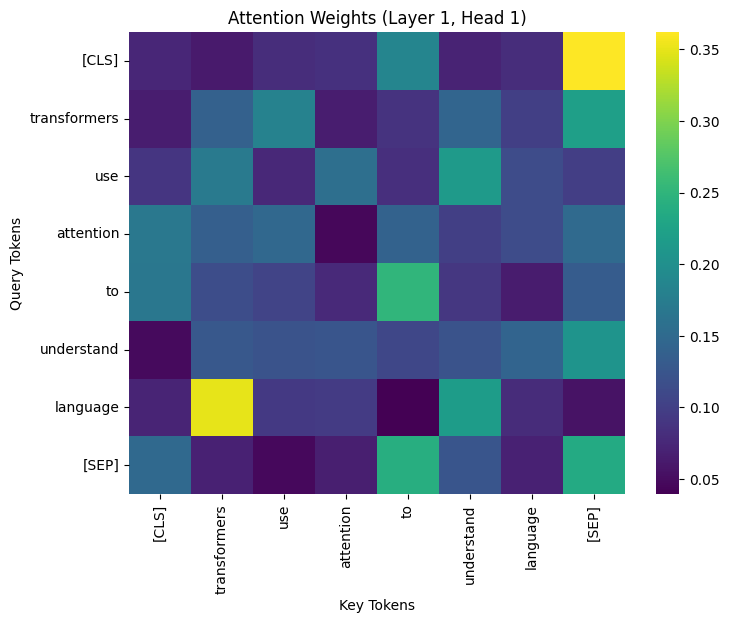

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    attention_matrix,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="viridis"
)
plt.title("Attention Weights (Layer 1, Head 1)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()

- This notebook visualizes the attention mechanism in a transformer model.
- Attention weights show how much each token attends to other tokens while generating representations.
- Each transformer layer contains multiple attention heads that capture different relationships between tokens.
- Visualizing attention helps in understanding why transformers are effective for language understanding.
